## **Exercise 02 : Bar**

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
pd.options.display.max_rows = 15

connection = sqlite3.connect('../data/checking-logs.sqlite')
commits = pd.read_sql('select timestamp as commits from checker where uid like "%user_%"', connection)
commits[['date', 'time']] = commits['commits'].apply(lambda x: pd.Series([i for i in x.split()]))
commits

# commits['time'] type is str, but because time col is written 
# in a format that, takes into account the order, we can eval it (str) with timestamp bins
bins = ['0:00:00', '03:59:59', '09:59:59,', '16:59:59', '23:59:59']
bins = [pd.Timestamp(x) for x in bins]
labels = ['night', 'morning', 'afternoon', 'evening']
commits['time'] = pd.cut(commits['time'], bins=bins, labels=labels)

commits = commits.groupby(['date',], observed=False)['time'].value_counts()
commits = commits.to_frame().unstack()
commits.columns = commits.columns.droplevel(0)
commits.columns.name = 'daytime'

commits

daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25
...,...,...,...,...
2020-05-17,0,2,10,36
2020-05-18,0,0,1,2
2020-05-19,0,12,18,4


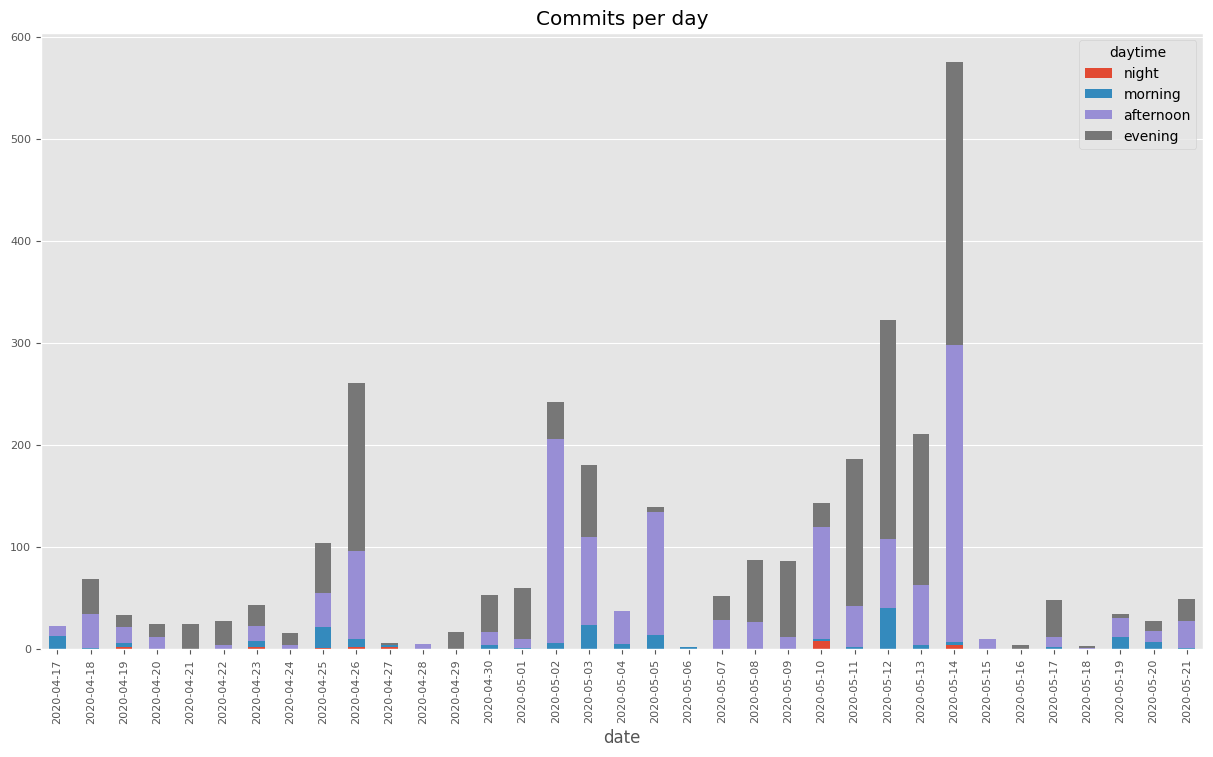

In [2]:
plt.style.use('ggplot')
ax = commits.plot.bar(fontsize=8, figsize = (15,8), title='Commits per day', rot=90, stacked=True)
ax.xaxis.grid(False)
plt.show()

In [3]:
connection.close()

In [4]:
commits.describe().max().sort_values(ascending=False).head(2)

daytime
afternoon    291.0
evening      277.0
dtype: float64

1. Q: When do our users usually commit the labs: in the night, morning, afternoon or evening?  
A: afternoon, evening

In [5]:
commits['total'] = commits['night'] + commits['morning'] + commits['afternoon'] + commits['evening']
commits.loc[commits['evening']>commits['afternoon']]['total'].sort_values(ascending=False).head(1)

date
2020-05-12    323
Name: total, dtype: int64

2. Q: Which day has: the most number of commits and at the same time, the number of commits in the evening is higher than in the afternoon?  
A: 2020-05-12